# Univariate Linear Regression: Weight vs MPG using Normal Equation (closed form)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("auto-mpg.csv")

In [3]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


In [4]:
df.tail()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
393,27.0,4,140.0,86.0,2790,15.6,82
394,44.0,4,97.0,52.0,2130,24.6,82
395,32.0,4,135.0,84.0,2295,11.6,82
396,28.0,4,120.0,79.0,2625,18.6,82
397,31.0,4,119.0,82.0,2720,19.4,82


**Exploratory Data Analysis**

In [5]:
df.shape

(398, 7)

In [6]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model-year        int64
dtype: object

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      2
weight          0
acceleration    0
model-year      0
dtype: int64

In [9]:
df['horsepower']=df['horsepower'].fillna(df['horsepower'].mean())

In [10]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model-year      0
dtype: int64

In [11]:
df.nunique()

mpg             129
cylinders         5
displacement     82
horsepower       94
weight          351
acceleration     95
model-year       13
dtype: int64

**Building Linear Regression from scratch**

**Step 1**: Form x and y matrix (p = weight, the input; q = mpg, the target)

In [12]:
p = df["weight"].values
q = df["mpg"].values
n = len(df)
X = np.column_stack([np.ones(n), p])
y = q.reshape(-1, 1)

print(X.shape, y.shape)
print(X[:5])
print(y[:5])

(398, 2) (398, 1)
[[1.000e+00 3.504e+03]
 [1.000e+00 3.693e+03]
 [1.000e+00 3.436e+03]
 [1.000e+00 3.433e+03]
 [1.000e+00 3.449e+03]]
[[18.]
 [15.]
 [18.]
 [16.]
 [17.]]


**Step 2**: Train test split (80% train, 20% test)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(318, 2) (80, 2)
(318, 1) (80, 1)


**Step 3**: Calculate transpose of X_train (XT)

In [14]:
def transpose(A):
    rows = A.shape[0]
    cols = A.shape[1]
    T = np.zeros((cols, rows))
    for i in range(rows):
        for j in range(cols):
            T[j, i] = A[i, j]
    return T

XT = transpose(X_train)
print(XT.shape)

(2, 318)


**Step 4**: Perform matrix multiplication XtX and Xty (training data only)

In [15]:
def matmul(A, B):
    r = A.shape[0]
    k = A.shape[1]
    k2 = B.shape[0]
    c = B.shape[1]
    assert k == k2
    C = np.zeros((r, c))
    for i in range(r):
        for j in range(c):
            total = 0
            for t in range(k):
                total += A[i, t] * B[t, j]
            C[i, j] = total
    return C

XtX = matmul(XT, X_train)
print(XtX.shape)
print(XtX)

(2, 2)
[[3.18000000e+02 9.44147000e+05]
 [9.44147000e+05 3.02719159e+09]]


In [16]:
Xty = matmul(XT, y_train)
print(Xty.shape)
print(Xty)

(2, 1)
[[7.50740000e+03]
 [2.05411808e+07]]


In [17]:
# cross-check against NumPy (verification only)
print(np.allclose(Xty, X_train.T @ y_train))
print(y_train.sum())

True
7507.4


**Step 5**: Perform Inverse $(X^T X)^{-1}$

In [18]:
def inverse(A):
    n = A.shape[0]
    assert A.shape == (n, n), "matrix must be square"

    M = np.hstack([A.astype(float), np.eye(n)])

    for col in range(n):
        pivot_row = col + np.argmax(np.abs(M[col:, col]))
        assert abs(M[pivot_row, col]) > 1e-12, "matrix is singular, no inverse"
        M[[col, pivot_row]] = M[[pivot_row, col]]

        M[col] = M[col] / M[col, col]

        for r in range(n):
            if r != col:
                M[r] = M[r] - M[r, col] * M[col]

    return M[:, n:]

XtX_inv = inverse(XtX)
print(XtX_inv)

print(np.allclose(XtX_inv, np.linalg.inv(XtX)))
print(np.allclose(matmul(XtX, XtX_inv), np.eye(XtX.shape[0])))

[[ 4.24968201e-02 -1.32542801e-05]
 [-1.32542801e-05  4.46420004e-09]]
True
True


**Step 6**: Multiply $(X^T X)^{-1}$ and $X^T y$ to get $\beta$

In [19]:
beta = matmul(XtX_inv, Xty)
print(beta)

[[ 4.67820634e+01]
 [-7.80524235e-03]]


In [20]:
def evaluate(X_, y_, beta):
    y_hat = matmul(X_, beta)
    res = y_ - y_hat
    rss = matmul(transpose(res), res)[0, 0]
    r2 = 1 - rss / ((y_ - y_.mean())**2).sum()
    rmse = (rss / len(y_)) ** 0.5
    return y_hat, res, rss, r2, rmse

y_hat_tr, res_tr, rss_tr, r2_tr, rmse_tr = evaluate(X_train, y_train, beta)
y_hat_te, res_te, rss_te, r2_te, rmse_te = evaluate(X_test, y_test, beta)

**Step 7**: Evaluate on train and test

In [21]:
errors = y_test - y_hat_te

mae = np.mean(np.abs(errors))
mse = np.mean(errors ** 2)
rmse = np.sqrt(mse)
r2 = 1 - np.sum(errors ** 2) / np.sum((y_test - y_test.mean()) ** 2)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 3.1177861992064466
MSE: 14.894861064636137
RMSE: 3.859386099451069
R² Score: 0.7229710573030761


**Visualization**

**Plot 1**: train and test data with the fitted line

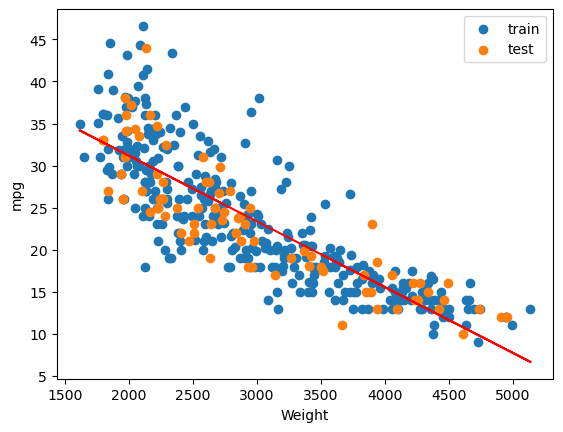

In [22]:
plt.scatter(X_train[:, 1], y_train, label="train")
plt.scatter(X_test[:, 1], y_test, label="test")
plt.plot(X[:, 1], X @ beta, color="red")
plt.xlabel("Weight"); plt.ylabel("mpg"); plt.legend()
plt.show()

**Plot 2**: Residuals vs predictions (test set)

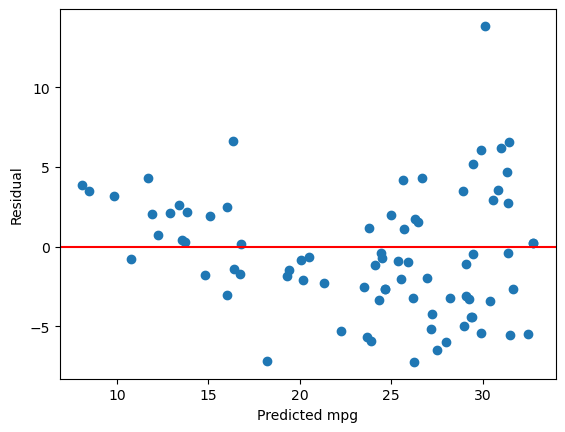

In [23]:
plt.scatter(y_hat_te, res_te)
plt.axhline(0, color="red")
plt.xlabel("Predicted mpg"); plt.ylabel("Residual")
plt.show()

**Plot 3**: Histogram of residuals (test set)

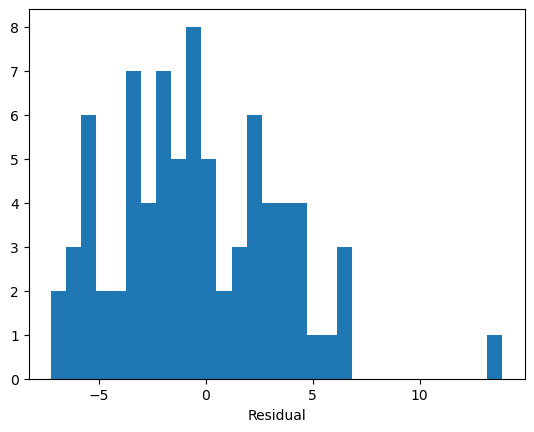

In [24]:
plt.hist(res_te, bins=30)
plt.xlabel("Residual")
plt.show()

**Plot 4**: Actual vs predicted (test set)

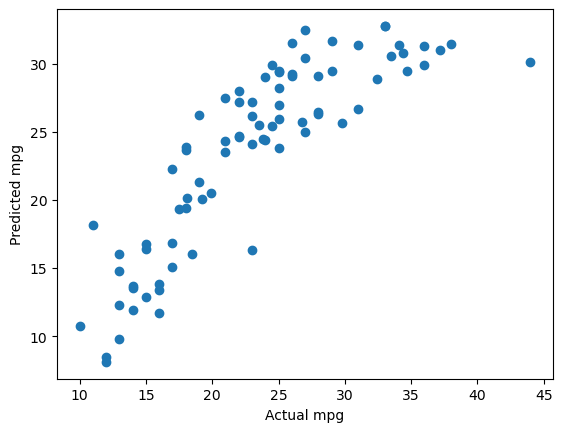

In [25]:
plt.scatter(y_test, y_hat_te)
plt.xlabel("Actual mpg"); plt.ylabel("Predicted mpg")
plt.show()

In [26]:
print(f"mpg = {beta[0, 0]:.2f} + ({beta[1, 0]:.5f}) x weight")
print(f"Train R2 = {r2_tr:.3f}, Test R2 = {r2_te:.3f}")

mpg = 46.78 + (-0.00781) x weight
Train R2 = 0.684, Test R2 = 0.723
